# 🏦 Bank Marketing Campaign
## 🤖 Model 1: Logistic Regression

Logistic Regression is a simple and effective
classification algorithm. It predicts the
probability of a customer subscribing to a
term deposit.

#Install & Import Libraries

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


## 📂 Step 1: Load Data

Loading the preprocessed data:
- train.csv → Training data (after SMOTE) : (63870, 48)
- test.csv  → Testing data  (original)    : (9042,  48)

In [2]:
# Load Data
train = pd.read_csv('train.csv')
test  = pd.read_csv('test.csv')

print("✅ Data loaded successfully!")
print("Train:", train.shape)
print("Test :", test.shape)

✅ Data loaded successfully!
Train: (63870, 48)
Test : (9042, 48)


## ✂️ Step 2: Split Features & Target

Separating features (X) from target (y)
to prepare data for model training.

In [3]:
# Split Features & Target
X_train = train.drop('y', axis=1)
y_train = train['y']

X_test = test.drop('y', axis=1)
y_test = test['y']

print("✅ Split done successfully!")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

✅ Split done successfully!
X_train: (63870, 47)
X_test : (9042, 47)
y_train: (63870,)
y_test : (9042,)


## 🤖 Step 3: Train Logistic Regression Model

Training the Logistic Regression model
on the training data.

In [5]:
from sklearn.linear_model import LogisticRegression

# Train Model
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

print("✅ Model trained successfully!")

✅ Model trained successfully!


## 📊 Step 4: Model Evaluation

Evaluating the model performance
on the test data using:
- Accuracy
- Classification Report (Precision, Recall, F1-Score)
- Confusion Matrix

In [6]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Predictions
y_pred = model.predict(X_test)

# Accuracy
print("✅ Accuracy:", accuracy_score(y_test, y_pred))

# Classification Report
print("\n📊 Classification Report:")
print(classification_report(y_test, y_pred))

✅ Accuracy: 0.876133598761336

📊 Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.94      0.93      7984
           1       0.46      0.38      0.42      1058

    accuracy                           0.88      9042
   macro avg       0.69      0.66      0.67      9042
weighted avg       0.87      0.88      0.87      9042



## 📊 Step 5: Confusion Matrix

Visualizing the model predictions
vs actual values.

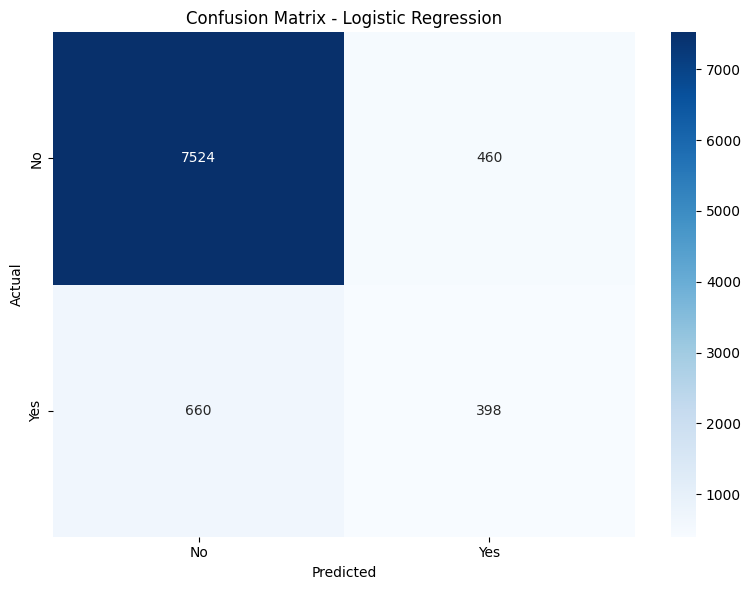

✅ Confusion Matrix saved!


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No','Yes'],
            yticklabels=['No','Yes'])
plt.title('Confusion Matrix - Logistic Regression')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix_lr.png', dpi=150)
plt.show()

print("✅ Confusion Matrix saved!")

## 📈 Step 6: ROC Curve & AUC Score

ROC Curve shows the trade-off between:
- True Positive Rate  (Recall)
- False Positive Rate

AUC Score: closer to 1.0 = better model ✅

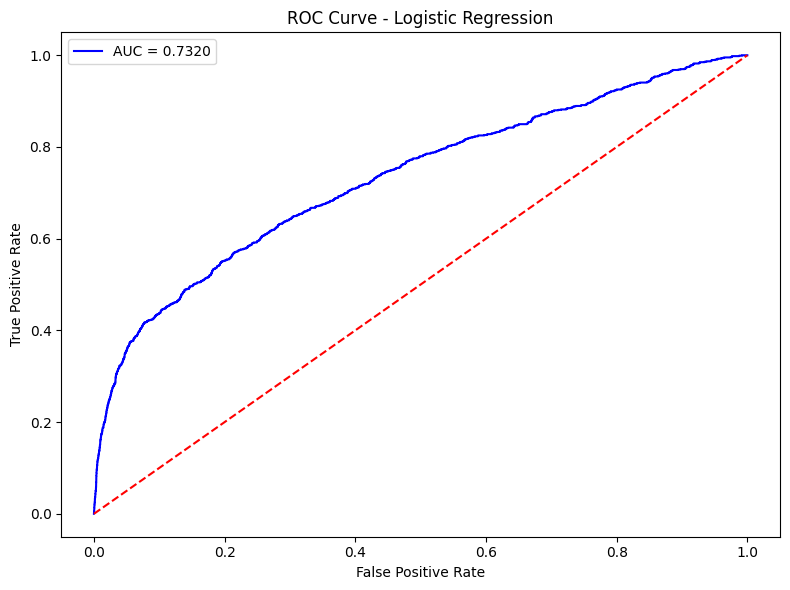

✅ AUC Score: 0.7320


In [8]:
from sklearn.metrics import roc_curve, roc_auc_score

# ROC Curve
y_prob = model.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='blue', label=f'AUC = {auc:.4f}')
plt.plot([0,1], [0,1], color='red', linestyle='--')
plt.title('ROC Curve - Logistic Regression')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.tight_layout()
plt.savefig('roc_curve_lr.png', dpi=150)
plt.show()

print(f"✅ AUC Score: {auc:.4f}")